In [ ]:
import re
import pandas as pd
import numpy as np
import nltk
#nltk.download('stopwords')
#nltk.download('punkt')
#nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from textblob import TextBlob
import joblib
import spacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt

DUOMENŲ PARUOŠIMAS - ištrinami paminėjimai (@naudotojas), nuorodos (kartu ir "url"), šypsenėlės, nereikšmingi žodžiai, tekstas pateikiamas pagrindinėmis žodžių formomis.
Duomenų failas subalansuojamas, kad įžeičiančių "tweet'ų" būtų tiek pat kiek neutralių.

ŽODŽIŲ ANALIZĖ - leidžia pamatyti, kokie žodžiai dominuoja duomenų rinkinyje - braižomas žodžių debesis.

C:\Users\vaici\AppData\Local\Temp\ipykernel_23876\2029397482.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_file = file.groupby('subtask_a').apply(


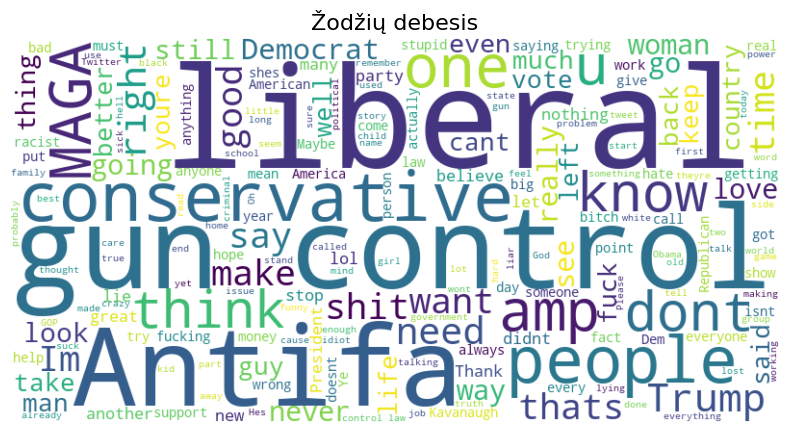

18                                     @USER @USER 🥀😢😢😢😢😢 so sad and preventable. Lift gun control in Chicago. Allow decent people to defend themselves.
19                                                    @USER You’re welcome! Yo! @USER and I were holding up a casual tournament watching you. Good shit!
20    @USER @USER This is what happens when you allow employees to destroy your brand.  Americans will never choose Football over our Flag. ALWAYS STAND
21                🛑 Truthfeed News 🛑 👉 'Schumer and Feinstein Go HYSTERICAL and Issue Unhinged Demands to Delay Kavanaugh Vote' #MAGA￼🇺🇸#2A #Prolife URL
22                                                                    #Scottish @USER @USER running out of excuses and #lies to justify her position URL
Name: tweet, dtype: object
18                                          sad preventable Lift gun control Chicago Allow decent people defend
19                                          Youre welcome ! Yo ! holding casual tournament watch

In [ ]:
def clean_text(text):
    text = re.sub(r'[@]\w+', '', text)
    text = re.sub(r"http\S+|www.\S+", '', text)
    text = re.sub(r"[^\w\s?!]", '', text)
    text = re.sub(r'\burl\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r"MENTION\d+", "", text)
    text = text.encode('utf-8', 'ignore').decode('utf-8')
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.lower() not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)


file = pd.read_csv('train.csv')
min_class_count = file['subtask_a'].value_counts().min()
balanced_file = file.groupby('subtask_a').apply(
    lambda x: x.sample(min_class_count, random_state=42)
).reset_index(drop=True)

balanced_file['cleaned_tweet'] = balanced_file['tweet'].apply(clean_text)

text_data = ' '.join(balanced_file['cleaned_tweet'].dropna().astype(str))

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate(text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Žodžių debesis", fontsize=16)
plt.show()


# pd.set_option('display.max_colwidth', None)

# print(balanced_file['tweet'].iloc[18:23]) 

# print(balanced_file['cleaned_tweet'].iloc[18:23])


MODELIO POŽYMIŲ SKAIČIAVIMAS - simbolių skaičius, didžiosios raidės, nuotaika (polarity), subjektyvumas, teksto ilgis. Teksto vektorizavimui naudoajamas TF-IDF ir Word2vec.

In [ ]:
def count_exclamations(text):
    return text.count('!')

def count_questions(text):
    return text.count('?')

def count_uppercase_words(text):
    return sum(1 for word in text.split() if word.isupper())


balanced_file['exclamation_count'] = balanced_file['cleaned_tweet'].apply(count_exclamations)
balanced_file['question_count'] = balanced_file['cleaned_tweet'].apply(count_questions)
balanced_file['uppercase_word_count'] = balanced_file['cleaned_tweet'].apply(count_uppercase_words)
balanced_file['polarity'] = balanced_file['cleaned_tweet'].apply(lambda x: TextBlob(x).sentiment.polarity)
balanced_file['subjectivity'] = balanced_file['cleaned_tweet'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
balanced_file['tweet_length'] = balanced_file['cleaned_tweet'].apply(len)

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(balanced_file['cleaned_tweet'])

nlp = spacy.load('en_core_web_md')
def get_word2vec_features(text):
    doc = nlp(text)
    word_vectors = [token.vector for token in doc if token.has_vector]
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(nlp.vocab.vectors.shape[1])

word2vec_features = np.array([get_word2vec_features(tweet) for tweet in balanced_file['cleaned_tweet']])

features = balanced_file[[
    'exclamation_count', 'question_count', 'uppercase_word_count',
    'polarity', 'subjectivity', 'tweet_length'
]].values

feature_sets = {
    "Sentimentų požymiai": balanced_file[['polarity', 'subjectivity']].values,
    "Teksto formatavimo požymiai": balanced_file[['exclamation_count', 'question_count', 'uppercase_word_count', 'tweet_length']].values,
    "TF-IDF vektorizavimas": X_tfidf.toarray(),
    "Word2vec vektorizavimas": word2vec_features,
    "Visi požymiai": np.hstack((X_tfidf.toarray(), features, word2vec_features)),
}

print(word2vec_features)

MODELIO APMOKYMAS, TIKSLUMO SKAIČIAVIMAS ĮVAIRIOMS POŽYMIŲ KOMBINACIJOMS.

In [4]:
results = {}

for feature_set_name, features in feature_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(features, balanced_file['subtask_a'], test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=5000, solver='lbfgs', penalty='l2')
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    precision = precision_score(y_test, y_pred, pos_label='OFF', average='binary')
    recall = recall_score(y_test, y_pred, pos_label='OFF', average='binary')
    f1 = f1_score(y_test, y_pred, pos_label='OFF', average='binary')
    accuracy = accuracy_score(y_test, y_pred)
    
    results[feature_set_name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Accuracy": accuracy,
    }

    print(f"Rezultatai: {feature_set_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print()

best_feature_set = max(results, key=lambda k: results[k]["F1-Score"])
print(f"Geriausias modelis: {best_feature_set}")

#išsaugomas modelis
joblib.dump(model, f'hate_speech_model_{best_feature_set}.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

Rezultatai: Sentimentų požymiai:
  Precision: 0.6904
  Recall: 0.5017
  F1-Score: 0.5811
  Accuracy: 0.6347

Rezultatai: Teksto formatavimo požymiai:
  Precision: 0.5676
  Recall: 0.4578
  F1-Score: 0.5068
  Accuracy: 0.5500

Rezultatai: TF-IDF vektorizavimas:
  Precision: 0.7411
  Recall: 0.6344
  F1-Score: 0.6836
  Accuracy: 0.7034

Rezultatai: Word2vec vektorizavimas:
  Precision: 0.6962
  Recall: 0.6625
  F1-Score: 0.6790
  Accuracy: 0.6835

Rezultatai: Visi požymiai:
  Precision: 0.7418
  Recall: 0.7143
  F1-Score: 0.7278
  Accuracy: 0.7301

Geriausias modelis: Visi požymiai


['tfidf_vectorizer.pkl']

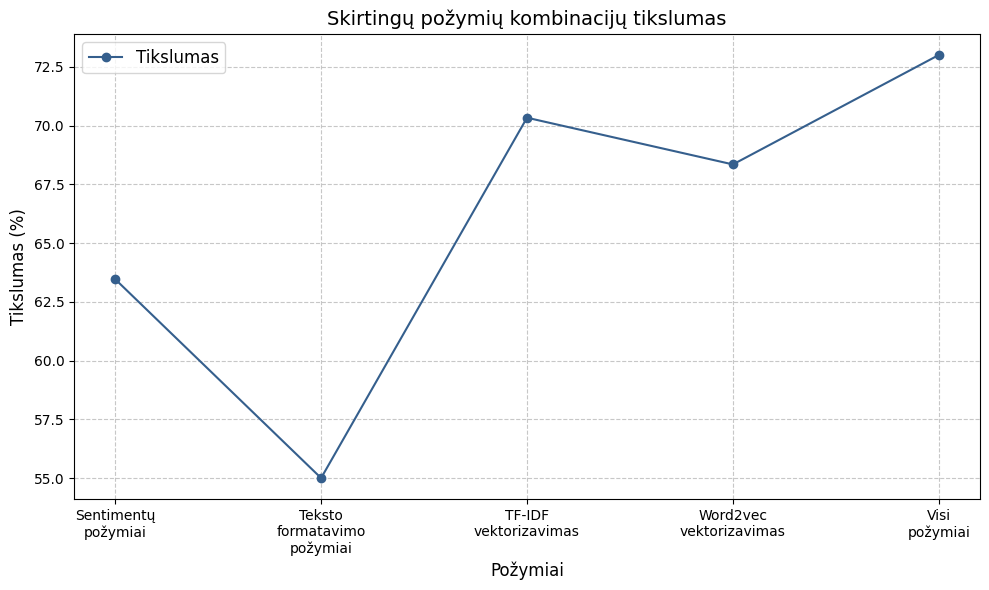

In [5]:
import matplotlib.pyplot as plt
from matplotlib.cm import viridis

feature_set_names = list(results.keys())
accuracies = [results[set_name]["Accuracy"] for set_name in feature_set_names]
formatted_labels = [label.replace(" ", "\n") for label in feature_set_names]

viridis_green = viridis(0.3)
plt.figure(figsize=(10, 6))
plt.plot(formatted_labels, [acc * 100 for acc in accuracies], marker='o', linestyle='-', color=viridis_green, label='Tikslumas')
plt.title("Skirtingų požymių kombinacijų tikslumas", fontsize=14)
plt.xlabel("Požymiai", fontsize=12)
plt.ylabel("Tikslumas (%)", fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


MODELIO TESTAVIMAS SU NAUJAIS DUOMENIMIS POLITIKOS TEMA (NAUDOJAMA TA PATI TEMA KAIP IR MODELIO APMOKYMUI) IR SU NAUJAIS DUOMENIMIS SEKSIZMO TEMA.

In [6]:
loaded_model = joblib.load('hate_speech_model_Visi požymiai.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

test_file = pd.read_csv('test.csv')

# Naujų duomenų požymiai testavimui
test_file['cleaned_tweet'] = test_file['tweet'].apply(clean_text)
test_file['exclamation_count'] = test_file['cleaned_tweet'].apply(count_exclamations)
test_file['question_count'] = test_file['cleaned_tweet'].apply(count_questions)
test_file['uppercase_word_count'] = test_file['cleaned_tweet'].apply(count_uppercase_words)
test_file['polarity'] = test_file['cleaned_tweet'].apply(lambda x: TextBlob(x).sentiment.polarity)
test_file['subjectivity'] = test_file['cleaned_tweet'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
test_file['tweet_length'] = test_file['cleaned_tweet'].apply(len)

X_tfidf_test = loaded_vectorizer.transform(test_file['cleaned_tweet'])

word2vec_test_features = np.array([get_word2vec_features(tweet) for tweet in test_file['cleaned_tweet']])

test_features = np.hstack((
    X_tfidf_test.toarray(),
    test_file[['exclamation_count', 'question_count', 'uppercase_word_count', 'polarity', 'subjectivity', 'tweet_length']].values,
    word2vec_test_features
))

#Naudojamas modelis spėjimu darymui
predictions = loaded_model.predict(test_features)

precision = precision_score(test_file['subtask_a'], predictions, pos_label='OFF', average='binary')
recall = recall_score(test_file['subtask_a'], predictions, pos_label='OFF', average='binary')
f1 = f1_score(test_file['subtask_a'], predictions, pos_label='OFF', average='binary')
accuracy = accuracy_score(test_file['subtask_a'], predictions)

print(f"Prediction Results:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  Accuracy: {accuracy:.4f}")
print()

Prediction Results:
  Precision: 0.5725
  Recall: 0.6583
  F1-Score: 0.6124
  Accuracy: 0.7674



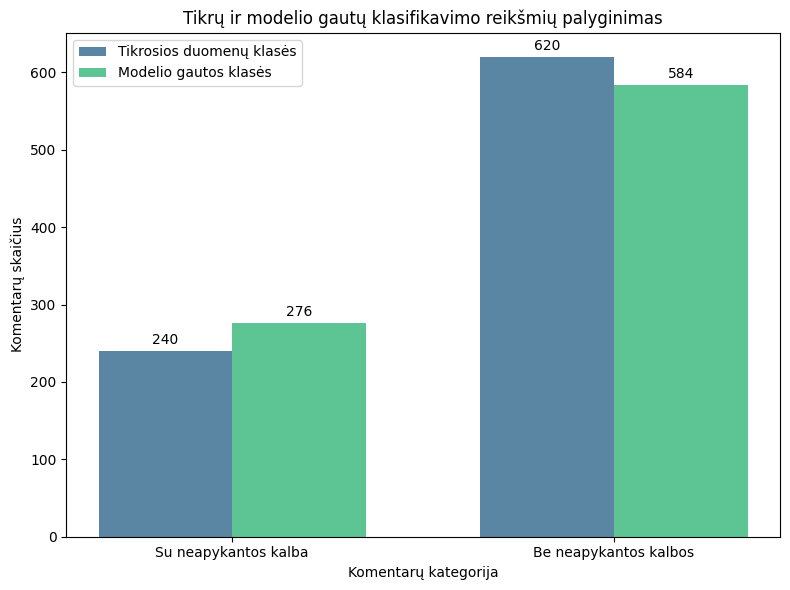

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import viridis

true_off = (test_file['subtask_a'] == 'OFF').sum()
true_not = (test_file['subtask_a'] == 'NOT').sum()

pred_off = (predictions == 'OFF').sum()
pred_not = (predictions == 'NOT').sum()

categories = ['Su neapykantos kalba', 'Be neapykantos kalbos']
true_values = [true_off, true_not]
predicted_values = [pred_off, pred_not]

x = np.arange(len(categories)) 
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 6))

viridis_colors = viridis(np.linspace(0, 1, 4))
bars_true = ax.bar(x - width / 2, true_values, width, label='Tikrosios duomenų klasės', alpha=0.8, color=viridis_colors[1])
bars_pred = ax.bar(x + width / 2, predicted_values, width, label='Modelio gautos klasės', alpha=0.8, color=viridis_colors[-2])

ax.set_xlabel('Komentarų kategorija')
ax.set_ylabel('Komentarų skaičius')
ax.set_title('Tikrų ir modelio gautų klasifikavimo reikšmių palyginimas')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

for bar in bars_true:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

for bar in bars_pred:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [8]:
loaded_model = joblib.load('hate_speech_model_Visi požymiai.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

new_file = pd.read_csv('new.csv')
new_file['sexist'] = new_file['sexist'].map({True: 'OFF', False: 'NOT'})

# Naujų duomenų požymiai testavimui
new_file['cleaned_tweet'] = new_file['text'].apply(clean_text)
new_file['exclamation_count'] = new_file['cleaned_tweet'].apply(count_exclamations)
new_file['question_count'] = new_file['cleaned_tweet'].apply(count_questions)
new_file['uppercase_word_count'] = new_file['cleaned_tweet'].apply(count_uppercase_words)
new_file['polarity'] = new_file['cleaned_tweet'].apply(lambda x: TextBlob(x).sentiment.polarity)
new_file['subjectivity'] = new_file['cleaned_tweet'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
new_file['tweet_length'] = new_file['cleaned_tweet'].apply(len)

X_tfidf_new = loaded_vectorizer.transform(new_file['cleaned_tweet'])

word2vec_new_features = np.array([get_word2vec_features(tweet) for tweet in new_file['cleaned_tweet']])

new_features = np.hstack((
    X_tfidf_new.toarray(),
    new_file[['exclamation_count', 'question_count', 'uppercase_word_count', 'polarity', 'subjectivity', 'tweet_length']].values,
    word2vec_new_features
))

#Naudojamas modelis spėjimu darymui
predictions = loaded_model.predict(new_features)

precision = precision_score(new_file['sexist'], predictions, pos_label='OFF', average='binary')
recall = recall_score(new_file['sexist'], predictions, pos_label='OFF', average='binary')
f1 = f1_score(new_file['sexist'], predictions, pos_label='OFF', average='binary')
accuracy = accuracy_score(new_file['sexist'], predictions)

print(f"Prediction Results:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  Accuracy: {accuracy:.4f}")
print()

Prediction Results:
  Precision: 0.1792
  Recall: 0.3566
  F1-Score: 0.2385
  Accuracy: 0.6978



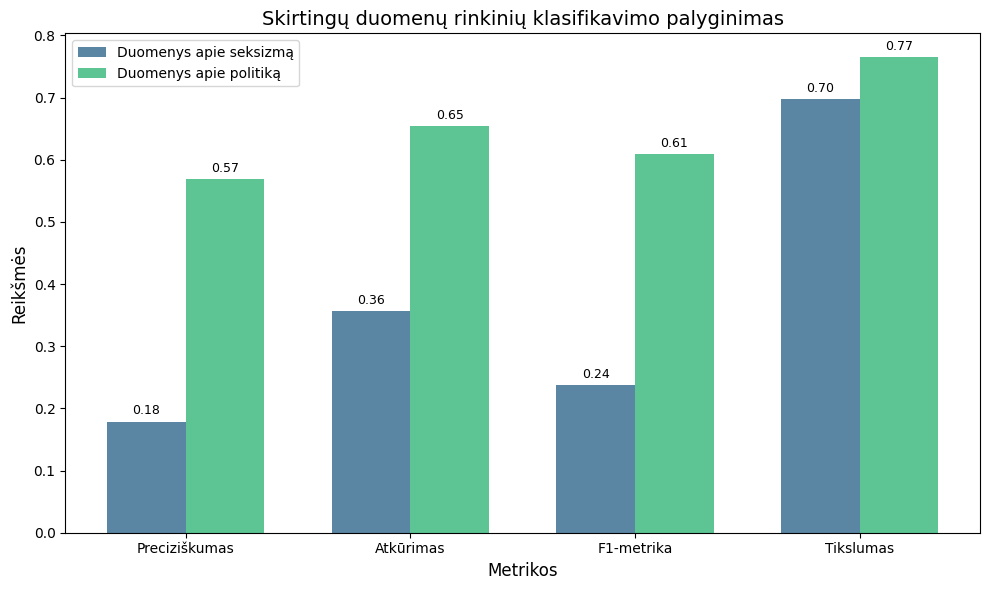

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import viridis

# Data
metrics = ['Preciziškumas', 'Atkūrimas', 'F1-metrika', 'Tikslumas']
sexism_values = [0.1787, 0.3566, 0.2381, 0.6972]
politics_values = [0.5688, 0.6542, 0.6085, 0.7651]

# Colors from Viridis
viridis_colors = viridis(np.linspace(0, 1, 4))
sexism_color = viridis_colors[1]   # Same color as used for "Tikrosios duomenų klasės"
politics_color = viridis_colors[-2]  # Same color as used for "Modelio gautos klasės"

x = np.arange(len(metrics))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, sexism_values, width, label='Duomenys apie seksizmą', color=sexism_color, alpha=0.8)
bars2 = ax.bar(x + width / 2, politics_values, width, label='Duomenys apie politiką', color=politics_color, alpha=0.8)

# Add labels, title, and legend
ax.set_xlabel('Metrikos', fontsize=12)
ax.set_ylabel('Reikšmės', fontsize=12)
ax.set_title('Skirtingų duomenų rinkinių klasifikavimo palyginimas', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend()

# Annotate bars with values
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
